# Solar System planets image classification
### Inteligencia Artirficial para los Sistemas de Control Autónomos
### Máster de Ciencia y Tecnología desde el Espacio


## Objectives

- Introduce some basic Machine Learning concepts.
- Work with a basic Machine Learning workflow.
- Illustrate an application of classical Machine Learning to image classification.
- Understand the importance of hyperparameter settings.

## Introduction

In this assignment we will implement a Computer Vision application of Machine Learning. We will train a classifier able to identify a planet of the Solar System given a picture of it. The main goal of this assignment is to implement a basic Machine Learning workflow and practice some tasks needed in any Machine Learning project, such as model training, model evaluation or hyperparameter optimization.

Remember that the workflow usually implemented in ML projects is as follows.

1. Data adquisition
2. Exploratory analysis
3. Data preprocessing
4. Model training
5. Model validation

This assignment uses a dataset created by Emirhan Bulut.

## Libraries import

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

## Load dataset

Given that the dataset is a collection of images, first we need to download them in order to build our feature matrix. To that end we use a nice feature of notebooks that allows to execute a system command. You do not need to know how the following command works, all you need is to know that it is going to download a zip file from Internet containing the images.

You can execute any shell command in Jupyter using "!", as the following line that downloads the dataset from a web server:

In [4]:
!wget https://github.com/emirhanai/Planets-and-Moons-Dataset-AI-in-Space/raw/main/Planets_Moons_Data.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
!unzip Planets_Moons_Data.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


Let's checkout if the dataset has been correctly downloaded.

In [8]:
!ls -l

total 21708
-rw-rw-rw-  1 narcopiso narcopiso   117465 Mar 19 08:35 'Copia de Pandas.ipynb'
drwxrwxrwx  2 narcopiso narcopiso     4096 Mar 19 09:33  Data
drwxrwxrwx  2 narcopiso narcopiso     4096 Mar 19 15:21  dataviz
-rw-rw-rw-  1 narcopiso narcopiso   375791 Mar 23 19:45  EDA_Exoatmospheres.ipynb
-rw-rw-rw-  1 narcopiso narcopiso    37187 Mar 19 08:35  EDA_practica1.ipynb
drwxrwxrwx 11 narcopiso narcopiso     4096 Apr 22 19:25  IASCA_Venv
-rw-rw-rw-  1 narcopiso narcopiso    34571 Mar 19 10:49  Pandas.ipynb
drwxrwxr-x 13 narcopiso narcopiso     4096 May  8  2022 'Planets and Moons'
-rw-rw-r--  1 narcopiso narcopiso 21015623 Apr 28 11:53  Planets_Moons_Data.zip
-rw-rw-r--  1 narcopiso narcopiso     1196 Mar 19 18:25  requirements.txt
-rw-rw-r--  1 narcopiso narcopiso   571595 Apr 22 19:09  sunspots_IASCA.ipynb
-rw-rw-rw-  1 narcopiso narcopiso    42106 Mar 19 09:52  Table.png


It would be better to visualize one of the images.

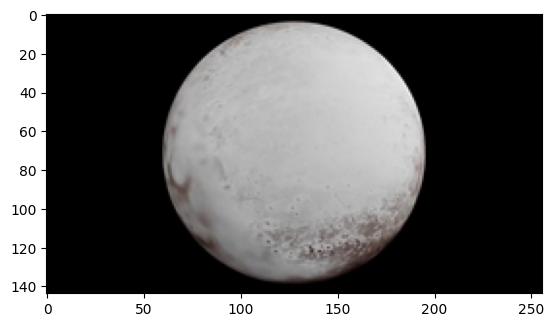

In [8]:
import os
import pandas as pd
import time
from tqdm.notebook import tqdm
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

from PIL import ImageOps

DATAPATH = "Planets and Moons"

img = Image.open(os.path.join(DATAPATH, "Pluto/Pluto (100).jpg"))
img.load()
plt.imshow(img)

In [9]:
type(img)

PIL.JpegImagePlugin.JpegImageFile

We can transform the image to a plain numpy array simply as.

In [10]:
np.asarray(img, dtype="uint8").shape

(144, 256, 3)

## Build the dataset

Given the collection of images, we need to extract the features to build the dataset. That is done in the following code, that you do not need to understand.

In [14]:
DATAPATH = "Planets and Moons"

print(DATAPATH)

columnNames = list()
columnNames.append('label')
size = 28 * 28 * 3

for i in range(size):
    pixel = str(i)
    columnNames.append('pixel' + pixel)

df = pd.DataFrame(columns = columnNames)

for dirs in os.listdir(DATAPATH):
    print("Iterating: " + dirs + " folder")

    for file in os.listdir(os.path.join(DATAPATH, dirs)):
        #print("Doing " + file)
        img = Image.open(os.path.join(DATAPATH, dirs, file))
        img.load()

        border = (58, 2, 58, 2) # left, top, right, bottom
        img = ImageOps.crop(img, border)
        img = img.resize((28, 28))

        # create a numpy array for image pixels
        imgdata = np.asarray(img, dtype="uint8")
        #print(imgdata.shape)
        imgdata = imgdata.reshape(1, -1)
        row = pd.DataFrame(imgdata)
        row.columns = columnNames[1:] # First entry is 'label', avoid it
        row['label'] = dirs

        df = pd.concat([df, row])


Planets and Moons
Iterating: Earth folder
Iterating: Jupiter folder
Iterating: MakeMake folder
Iterating: Mars folder
Iterating: Mercury folder
Iterating: Moon folder
Iterating: Neptune folder
Iterating: Pluto folder
Iterating: Saturn folder
Iterating: Uranus folder
Iterating: Venus folder


The variable df contains a dataframe with the images in a Machine Learning friendly format. The process of building the dataset may be time-consuming in case of large amount of data. For this reason it is quite common to store it in disk.

In [15]:
df.to_csv("planets.csv", index=False)

This file has been created in the virtual machine, so you do not have direct access to it, but you can still download it with the following code.

In [16]:
from IPython.display import FileLink

display(FileLink("planets.csv"))

c:\Users\dovak\Documents\Ciencia y tecnologia desde el espacio\02Cuatri\IASCA\EDA\MUCYT_IASCA\planets.csv

## Exploratory analysis

As usual, we try to identify NaN and null values, number of instances, attributes and classes, outlayers, correlations and in general any information about our data that helps us to better understand it and hence train better models. You may be interested (and you certainly should be) in taking a look at the images, download them [from this link](https://github.com/dfbarrero/dataCourse/raw/master/assignments/planets/Planets_Moons_Data.zip).

In [19]:
## THIS EDA IS AN EXERCISE
## YOUR CODE HERE

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("planets.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 1.2. Dimensiones y tipos de datos

Comprobamos el número de instancias, atributos y tipo de dato de las columnas.

In [20]:
print(f"Filas (imágenes): {df.shape[0]}")
print(f"Columnas (1 label + {df.shape[1]-1} píxeles): {df.shape[1]}")
print(f"Tipo columna 'label': {df['label'].dtype}")
print(f"Tipo columnas píxeles: {df.drop('label', axis=1).dtypes.unique()}")

Filas (imágenes): 1638
Columnas (1 label + 2352 píxeles): 2353
Tipo columna 'label': str
Tipo columnas píxeles: [dtype('int64')]


## 1.3. NaN values

Verificamos si el dataset contiene valores faltantes.

In [21]:
print(f"Total valores nulos: {df.isnull().sum().sum()}")

Total valores nulos: 0


## 1.4. Balance de clases

Comprobamos cuántas imágenes hay por planeta. Un dataset desbalanceado
sesgaría el modelo hacia las clases más representadas.

label
Earth       149
Jupiter     149
MakeMake    149
Mars        149
Mercury     149
Neptune     149
Pluto       149
Saturn      149
Uranus      149
Venus       149
Moon        148
Name: count, dtype: int64


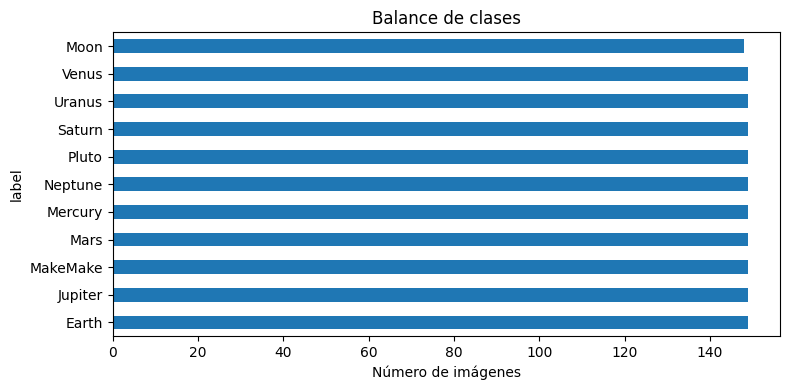

In [22]:
counts = df['label'].value_counts()
print(counts)

counts.plot(kind='barh', figsize=(8, 4))
plt.xlabel('Número de imágenes')
plt.title('Balance de clases')
plt.tight_layout()
plt.show()

### 5. Distribución de intensidad de píxel por clase

Visualizamos la distribución de intensidades agrupada por planeta para ver si las clases son distinguibles por sus valores de píxel. Muestreamos 1 decada 20 píxeles para no saturar la memoria.

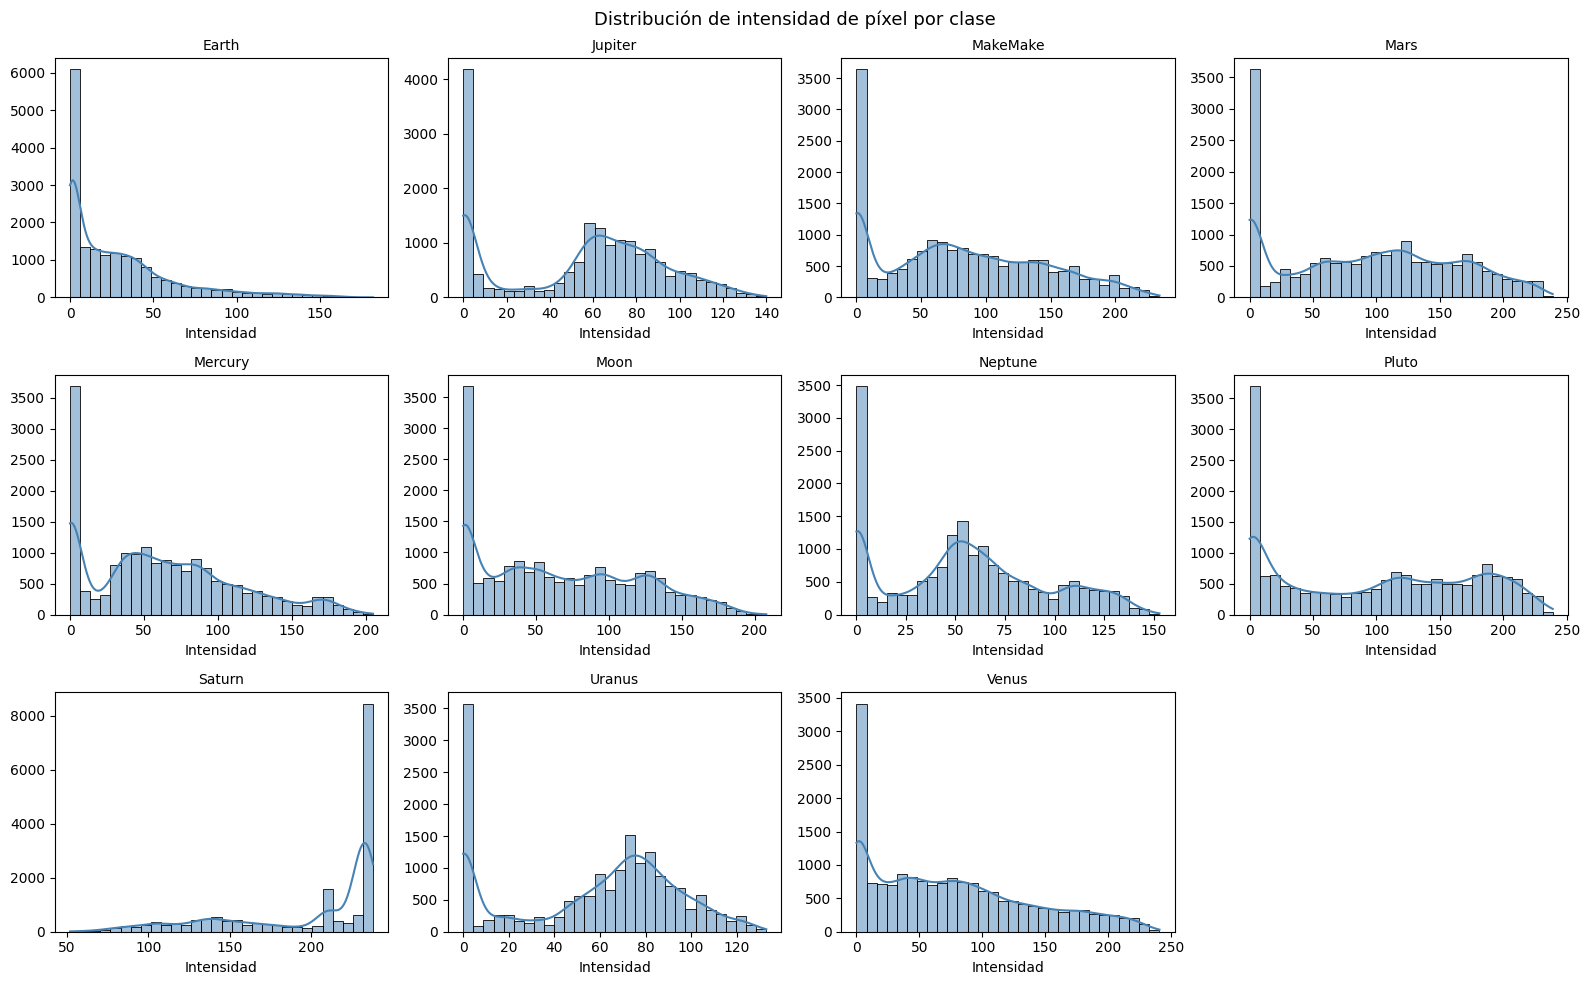

In [24]:
pixel_cols = [c for c in df.columns if c.startswith('pixel')]
sample_pixels = pixel_cols[::20]
labels = sorted(df['label'].unique())

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=False)
fig.suptitle('Distribución de intensidad de píxel por clase', fontsize=13)

for idx, planet in enumerate(labels):
    ax = axes[idx // 4][idx % 4]
    vals = df[df['label'] == planet][sample_pixels].values.flatten()
    sns.histplot(vals, ax=ax, kde=True, bins=30,
                 color='steelblue', kde_kws={'clip': (0, 255)})
    ax.set_title(planet, fontsize=10)
    ax.set_xlabel('Intensidad')
    ax.set_ylabel('')

axes[2][3].axis('off')
plt.tight_layout()
plt.show()

## 1.6. Imagen media por clase

Reconstruimos la imagen media de cada clase. Las imágenes fueron preprocesadas
antes de guardarse en el CSV: recortadas, redimensionadas a 28×28 píxeles y
aplanadas. El reshape correcto para reconstruirlas es `(28, 28, 3)` ya que
PIL aplana en formato (H, W, C) con canales RGB intercalados.

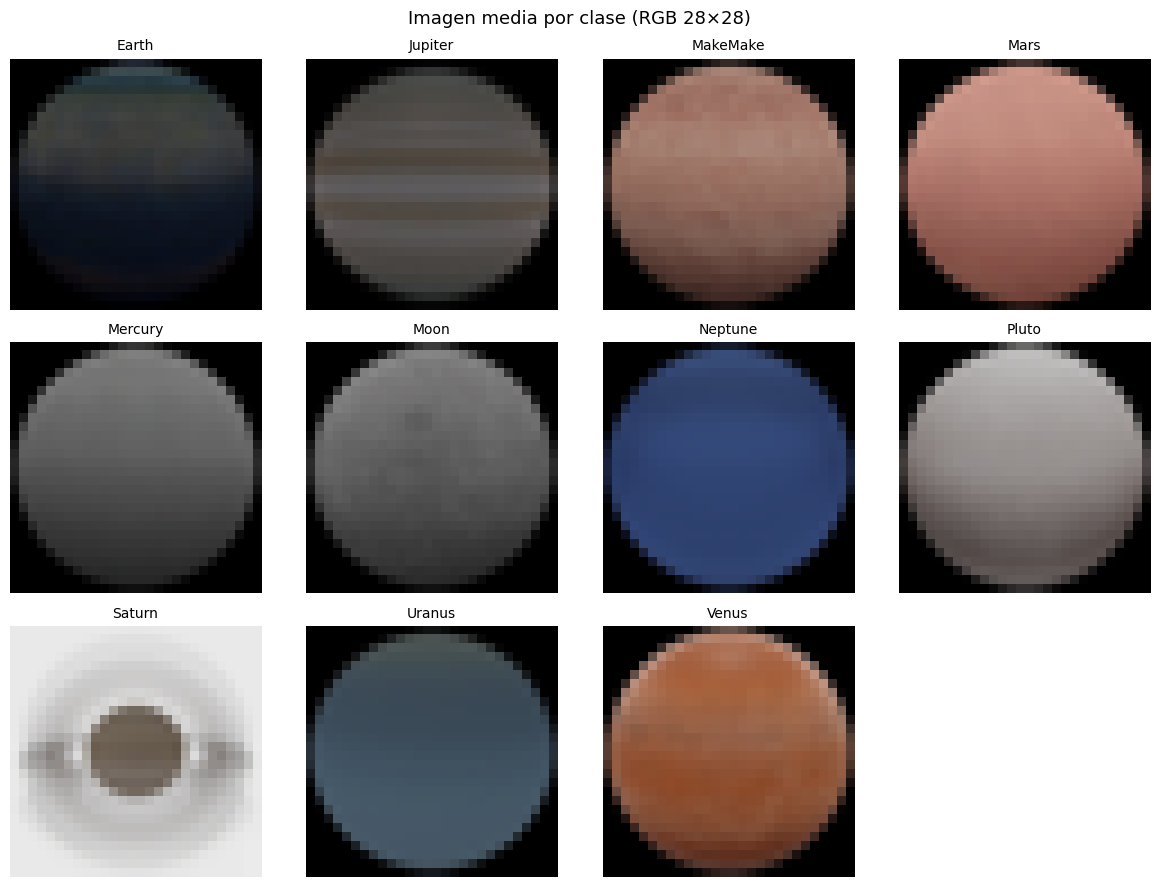

In [25]:
pixel_cols = [c for c in df.columns if c.startswith('pixel')]
labels = sorted(df['label'].unique())

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle("Imagen media por clase (RGB 28×28)", fontsize=13)

for idx, planet in enumerate(labels):
    ax = axes[idx // 4][idx % 4]
    mean_vals = df[df['label'] == planet][pixel_cols].mean().values.astype(np.uint8)
    ax.imshow(mean_vals.reshape(28, 28, 3), interpolation='nearest')
    ax.set_title(planet, fontsize=10)
    ax.axis('off')

axes[2][3].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
count,1638.00000,1638.00000,1638.00000,1638.00000,1638.00000,1638.00000,1638.00000,1638.00000,1638.00000,1638.00000,...,1638.00000,1638.00000,1638.00000,1638.00000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000
mean,21.19475,21.19475,21.19475,21.19475,21.19475,21.19475,21.19475,21.19475,21.19475,21.19475,...,21.19475,21.19475,21.19475,21.19475,21.376679,21.376679,21.376679,21.376679,21.376679,21.376679
std,67.02165,67.02165,67.02165,67.02165,67.02165,67.02165,67.02165,67.02165,67.02165,67.02165,...,67.02165,67.02165,67.02165,67.02165,67.596943,67.596943,67.596943,67.596943,67.596943,67.596943
min,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,233.00000,233.00000,233.00000,233.00000,233.00000,233.00000,233.00000,233.00000,233.00000,233.00000,...,233.00000,233.00000,233.00000,233.00000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000


The conclusion should be that the dataset is perfecty balanced with 11 classes, clean, without outlayers and valid for predictive modeling.

## Preprocess data

Our data have values between 0 and 255, which is not optimal for some of the algorithms we will try, so we normalize them. In this case the variance of our attributes is quite similar, if not identical, so normalization will not make a big difference, however, we will do it, but before that we build the feature matrix and target vector as Scikit-Learn requires.

In [26]:
x = df.drop("label", axis=1)
y = df["label"]

display(x.head())
display(y.head())

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


0    Earth
1    Earth
2    Earth
3    Earth
4    Earth
Name: label, dtype: str

Now we standarize our data.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(x)
X = scaler.transform(x)

X[0]

array([-0.31633394, -0.31633394, -0.31633394, ..., -0.31633394,
       -0.31633394, -0.31633394], shape=(2352,))

We split our data into train and test datasets.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print(f"X shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X shape: (1638, 2352)
X_train shape: (1146, 2352)
X_test shape: (492, 2352)


## Predictive modelling

### Set up a baseline

In order to assess correctly our model, we first need something to compare with. Absolute metrics have little meaning without a context. To this end it is quite common to apply a dumb forecasting just to have an estimation of the magnitude of the metrics. In our case we will always predict the most frequent class.

In [29]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X, y)
y_model = dummy_clf.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_model)

0.08739837398373984

In [31]:
y_model[:10]

array(['Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth',
       'Earth', 'Earth', 'Earth'], dtype='<U5')

This dummy classifier always classifies its input as 'Earth'. Now we are going to train several types of classifiers trying to improve our baseline accuracy; this is a standard practice in Machine Learning, remember that the No Free Lunch Theorem says that *a priori* we do not know which learning algorithm will perforn better.

We will use accuracy as metric, given that it is a pretty standard classification task with a balanced dataset.

#### K-NN classifier

Model fit:

In [41]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_model = model.predict(X_test)

Model evaluation:

In [33]:
from sklearn.metrics import accuracy_score

results = {}

results['knn'] = accuracy_score(y_test, y_model)
results['knn']

0.9878048780487805

#### Support Vector Machine (SVM) classifier

In [34]:
from sklearn.svm import SVC

model = SVC(C=1)

model.fit(X_train, y_train)
y_model = model.predict(X_test)

In [35]:
results['svm'] = accuracy_score(y_test, y_model)
results['svm']

0.9512195121951219

#### Classification tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=None)
model.fit(X_train, y_train)
y_model = model.predict(X_test)

In [38]:
results['tree'] = accuracy_score(y_test, y_model)

Finally, we compare the accuracy of our models:

In [39]:
results

{'knn': 0.9878048780487805,
 'svm': 0.9512195121951219,
 'tree': 0.9796747967479674}

# Exercises

### Initial steps

1. Understand the workflow implemented in this notebook. You do not need to understand the details of the code but of course it is better if you can understand it.

2. Complete this notebook filling in the EDA section.

### Hyper parameter optimization

1. Train a KNN model for different values of *n_neighbors* and plot its accuracy.

K=  1 → train: 1.0000 | test: 1.0000
K=  3 → train: 0.9939 | test: 0.9898
K=  5 → train: 0.9904 | test: 0.9878
K=  7 → train: 0.9764 | test: 0.9695
K=  9 → train: 0.9695 | test: 0.9553
K= 11 → train: 0.9616 | test: 0.9289
K= 15 → train: 0.9180 | test: 0.8923
K= 21 → train: 0.8857 | test: 0.8679


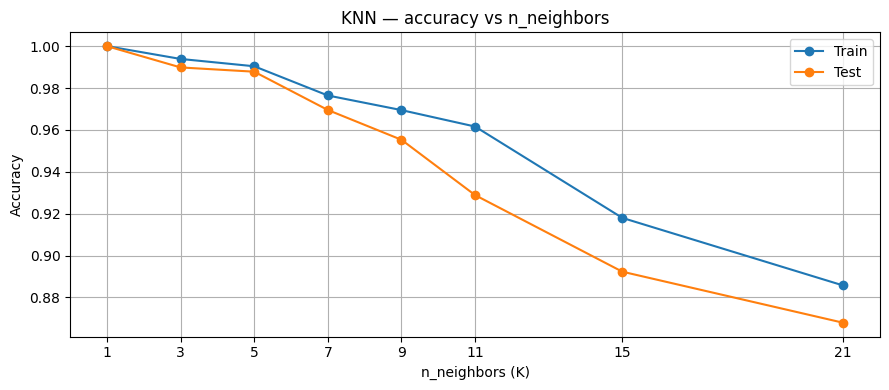

In [48]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_train_scores = []
knn_test_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    knn_train_scores.append(model.score(X_train, y_train))
    knn_test_scores.append(model.score(X_test, y_test))
    print(f"K={k:3d} → train: {knn_train_scores[-1]:.4f} | test: {knn_test_scores[-1]:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(k_values, knn_train_scores, marker='o', label='Train')
plt.plot(k_values, knn_test_scores, marker='o', label='Test')
plt.xlabel('n_neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN — accuracy vs n_neighbors')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

2. Train a SVM classifier for different values of *C* and plot its accuracy. Search in Internet which values of C are reasonable.

C= 0.001 → train: 0.0986 | test: 0.0732
C=  0.01 → train: 0.1719 | test: 0.1545
C=   0.1 → train: 0.8447 | test: 0.8191
C=     1 → train: 0.9729 | test: 0.9512
C=    10 → train: 1.0000 | test: 1.0000
C=   100 → train: 1.0000 | test: 1.0000


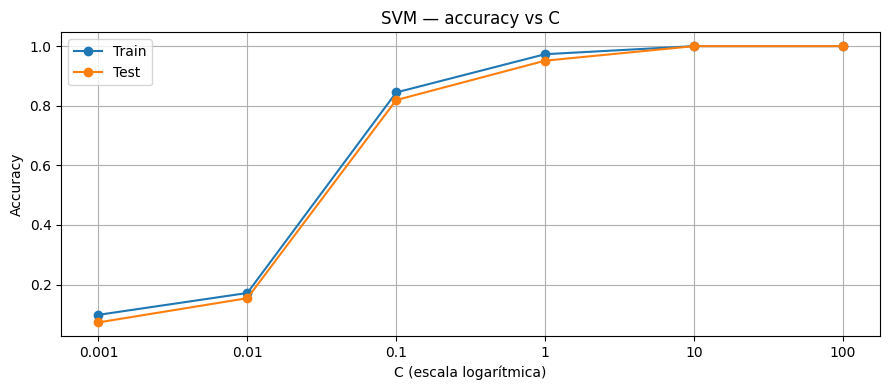

In [49]:
from sklearn.svm import SVC

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
svm_train_scores = []
svm_test_scores = []

for c in C_values:
    model = SVC(C=c)
    model.fit(X_train, y_train)
    svm_train_scores.append(model.score(X_train, y_train))
    svm_test_scores.append(model.score(X_test, y_test))
    print(f"C={c:6} → train: {svm_train_scores[-1]:.4f} | test: {svm_test_scores[-1]:.4f}")

plt.figure(figsize=(9, 4))
plt.plot([str(c) for c in C_values], svm_train_scores, marker='o', label='Train')
plt.plot([str(c) for c in C_values], svm_test_scores, marker='o', label='Test')
plt.xlabel('C (escala logarítmica)')
plt.ylabel('Accuracy')
plt.title('SVM — accuracy vs C')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

3. Train a classification tree for diferent values of *max_depth* and plot its accuracy. This hyperparameter determines the maximun depth that is allowed to the learned tree.

max_depth=1     → train: 0.1902 | test: 0.1443
max_depth=2     → train: 0.3743 | test: 0.3089
max_depth=3     → train: 0.5576 | test: 0.4898
max_depth=5     → train: 0.7391 | test: 0.6870
max_depth=7     → train: 0.9564 | test: 0.9289
max_depth=10    → train: 0.9974 | test: 0.9715
max_depth=15    → train: 1.0000 | test: 0.9837
max_depth=20    → train: 1.0000 | test: 0.9919
max_depth=None  → train: 1.0000 | test: 0.9756


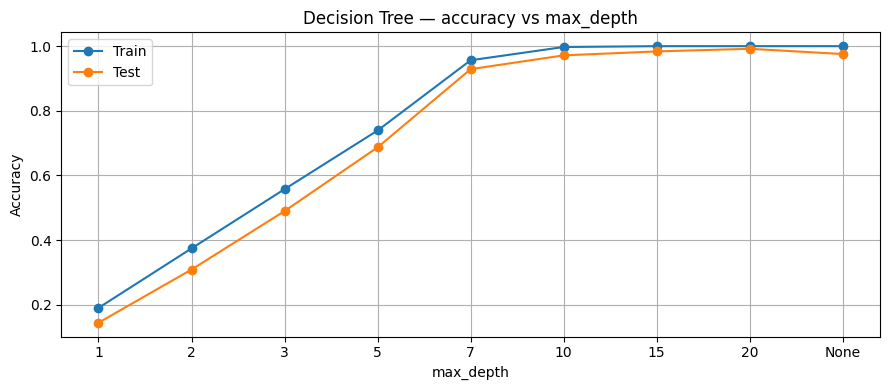

In [ ]:
from sklearn.tree import DecisionTreeClassifier

depth_values = [1, 2, 3, 5, 7, 10, 15, 20, None]
tree_train_scores = []
tree_test_scores = []

for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)
    tree_train_scores.append(model.score(X_train, y_train))
    tree_test_scores.append(model.score(X_test, y_test))
    print(f"max_depth={str(d):5} → train: {tree_train_scores[-1]:.4f} | test: {tree_test_scores[-1]:.4f}")

x_labels = [str(d) for d in depth_values]
plt.figure(figsize=(9, 4))
plt.plot(x_labels, tree_train_scores, marker='o', label='Train')
plt.plot(x_labels, tree_test_scores, marker='o', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — accuracy vs max_depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Cross-validation

1. The validation done above, depending on the size of the dataset and its properties, may not be very reliable. Evaluate the three previous classifiers with 10-folders cross validation and fill the following table and think about to what extend you are free to select any number of folds in cross validation.

| Model | Accuracy | Accuracy (10-CV) |
| ---   | --- | --- |
| Baseline   |   -  |  0.0867 ± 0.0024  |
| KNN   |  1 | 0.9896 ± 0.0179 |
| SVM   | 1 | 0.9970 ± 0.0041|
| Tree  |0.9756 | 0.9756 ± 0.0220|

In [51]:
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline_cv = cross_val_score(baseline, X, y, cv=10)
print(f"Baseline  — Accuracy: {baseline_cv.mean():.4f} ± {baseline_cv.std():.4f}")

Baseline  — Accuracy: 0.0867 ± 0.0024


KNN

In [52]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn_cv = cross_val_score(knn, X, y, cv=10)
print(f"KNN (K=1) — Accuracy: {knn_cv.mean():.4f} ± {knn_cv.std():.4f}")

KNN (K=1) — Accuracy: 0.9896 ± 0.0179


SVM

In [53]:
from sklearn.svm import SVC

svm = SVC(C=10)
svm_cv = cross_val_score(svm, X, y, cv=10)
print(f"SVM (C=10) — Accuracy: {svm_cv.mean():.4f} ± {svm_cv.std():.4f}")

SVM (C=10) — Accuracy: 0.9970 ± 0.0041


Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=20)
tree_cv = cross_val_score(tree, X, y, cv=10)
print(f"Tree (depth=20) — Accuracy: {tree_cv.mean():.4f} ± {tree_cv.std():.4f}")

Tree (depth=20) — Accuracy: 0.9756 ± 0.0220


2. Now compare the standard deviation of the accuracy estimated with cross validation for different number of folds (5 and 10). Fill out the following table and try to identify any pattern.

| Model | $\sigma$ (cv=10) | $\sigma$ (cv=5) |
| ---   | --- | --- |
| KNN   |  0.0179   |  0.0205   |
| SVM   | 0.0041 | 0.0121|
| Tree  | 0.0220 | 0.0094|

KNN

In [55]:
knn_cv5  = cross_val_score(KNeighborsClassifier(n_neighbors=1), X, y, cv=5)

print(f"KNN  cv=5 → {knn_cv5.mean():.4f}  ± {knn_cv5.std():.4f}")

KNN  cv=5 → 0.9841  ± 0.0205


SVM

In [57]:
svm_cv5  = cross_val_score(SVC(C=10), X, y, cv=5)

print(f"SVM  cv=5 → {svm_cv5.mean():.4f}  ± {svm_cv5.std():.4f}")

SVM  cv=5 → 0.9884  ± 0.0121


Tree

In [59]:
tree_cv5 = cross_val_score(DecisionTreeClassifier(max_depth=20), X, y, cv=5)

print(f"Tree cv=5 → {tree_cv5.mean():.4f}  ± {tree_cv5.std():.4f}")

Tree cv=5 → 0.9847  ± 0.0094


### Alternative evaluation methods

1. Display the confusion matrix for the tree models trained with the train dataset. Do they fail/success in the same way?

KNN

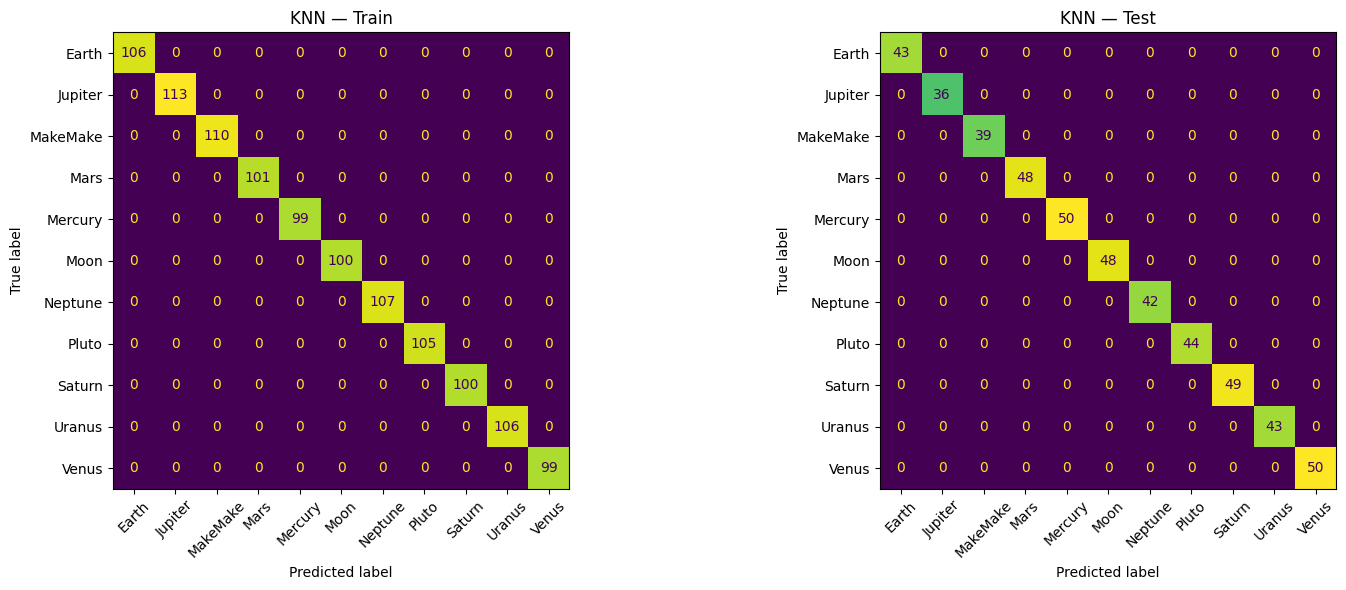

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_estimator(
    knn_model, X_train, y_train,
    ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title('KNN — Train')

ConfusionMatrixDisplay.from_estimator(
    knn_model, X_test, y_test,
    ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title('KNN — Test')
plt.tight_layout()
plt.show()

SVM

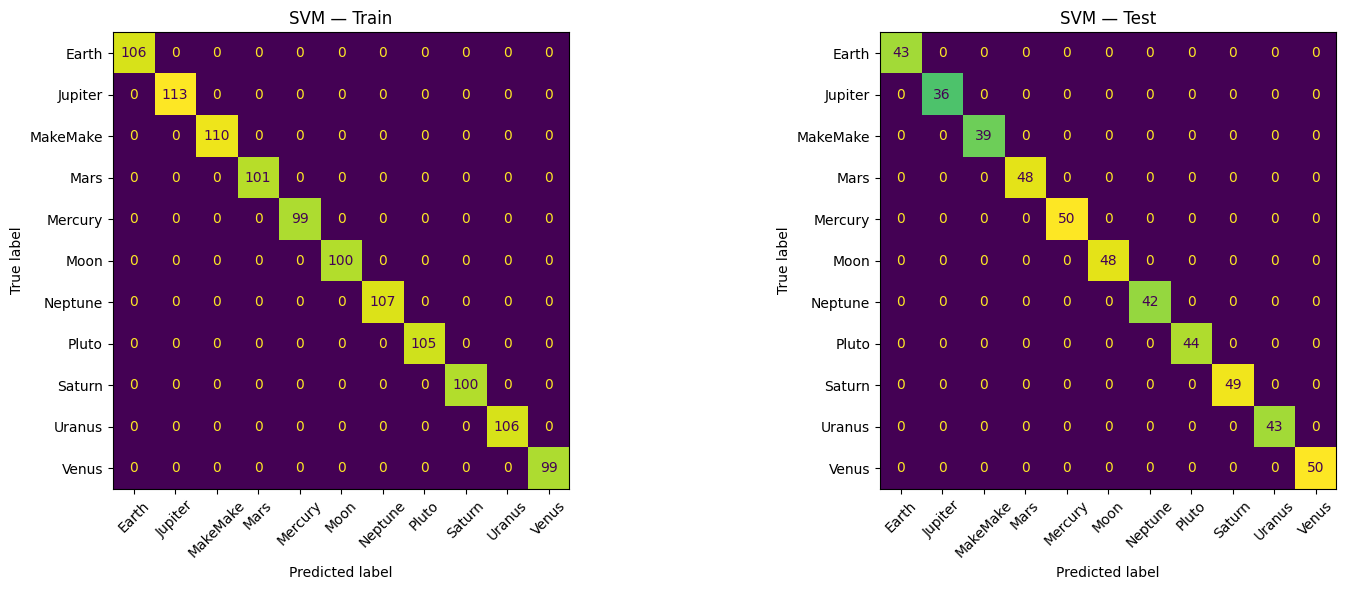

In [65]:
svm_model = SVC(C=10)
svm_model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_estimator(
    svm_model, X_train, y_train,
    ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title('SVM — Train')

ConfusionMatrixDisplay.from_estimator(
    svm_model, X_test, y_test,
    ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title('SVM — Test')
plt.tight_layout()
plt.show()

Tree

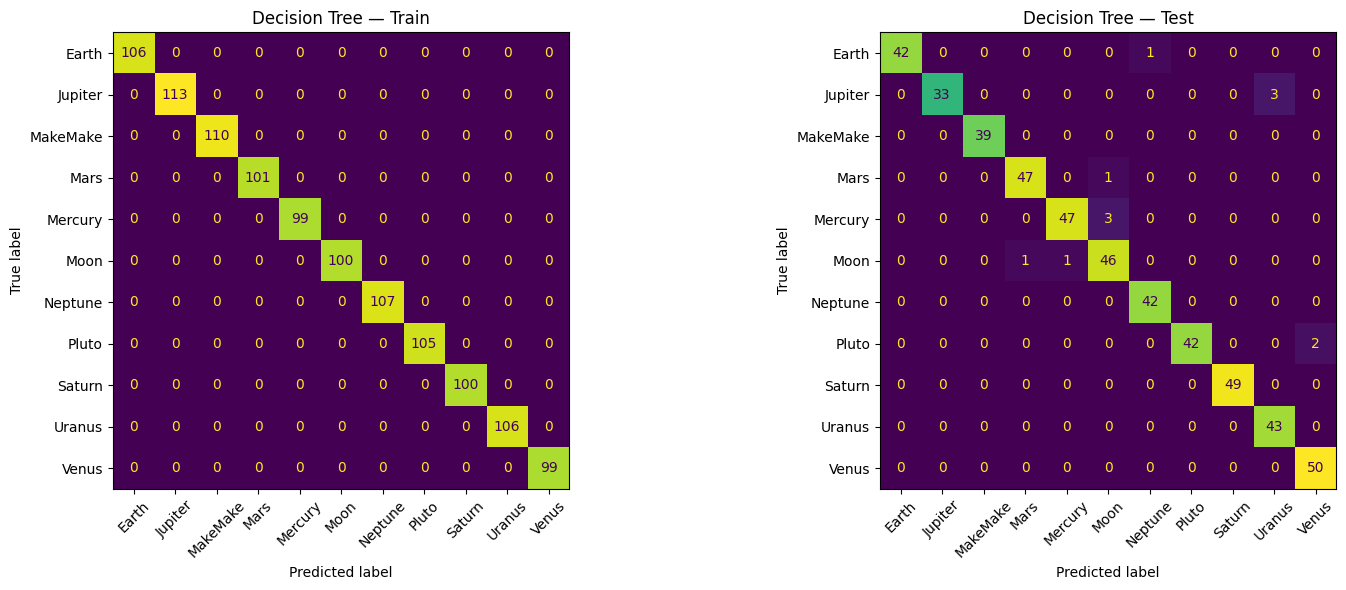

In [66]:
tree_model = DecisionTreeClassifier(max_depth=20)
tree_model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_estimator(
    tree_model, X_train, y_train,
    ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title('Decision Tree — Train')

ConfusionMatrixDisplay.from_estimator(
    tree_model, X_test, y_test,
    ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title('Decision Tree — Test')
plt.tight_layout()
plt.show()

2. Scikit-Learn comes with a handy function named *classification_report*, that provides a range of evaluation metrics for classifiers. Search information about this function and provide a report of the SVM classifier.

In [67]:
from sklearn.metrics import classification_report

svm_model = SVC(C=10)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Earth       1.00      1.00      1.00        43
     Jupiter       1.00      1.00      1.00        36
    MakeMake       1.00      1.00      1.00        39
        Mars       1.00      1.00      1.00        48
     Mercury       1.00      1.00      1.00        50
        Moon       1.00      1.00      1.00        48
     Neptune       1.00      1.00      1.00        42
       Pluto       1.00      1.00      1.00        44
      Saturn       1.00      1.00      1.00        49
      Uranus       1.00      1.00      1.00        43
       Venus       1.00      1.00      1.00        50

    accuracy                           1.00       492
   macro avg       1.00      1.00      1.00       492
weighted avg       1.00      1.00      1.00       492



### Predictions on new data

We train models because we want to use them with data that does not belong to our dataset. We first train a production model evaluating its performance using the best scoring configuration we have seen so far, which is a 1-NN classifier (KNN with K=1).

In [74]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

model = KNeighborsClassifier(n_neighbors=1)

print(f"5-CV accuracy estimation: {cross_val_score(model, X, y, cv=5).mean()}")

5-CV accuracy estimation: 0.9841444767658686


We've got a 99'7% accuracy! It seeems that our model is almost perfect, so we move on to put it into production, to this end we train it with the whole dataset for best performance.

In [80]:
model.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


That's nice, we finally have our model ready for fun. Now it is time to download an image.

In [81]:
from PIL import Image
import requests
from io import BytesIO

url = 'https://github.com/dfbarrero/dataCourse/raw/master/assignments/planets/earth.jpg'

response = requests.get(url)
img = Image.open(BytesIO(response.content))

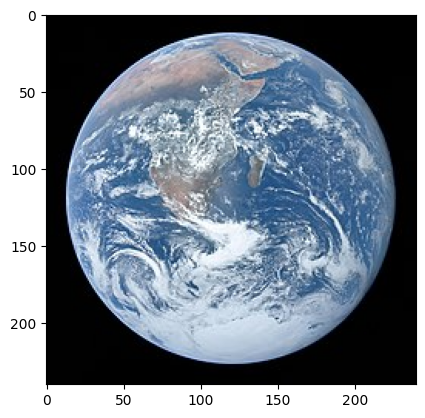

In [76]:
plt.imshow(img)

Good, now we have to preprocess the image to make our classifier happy.

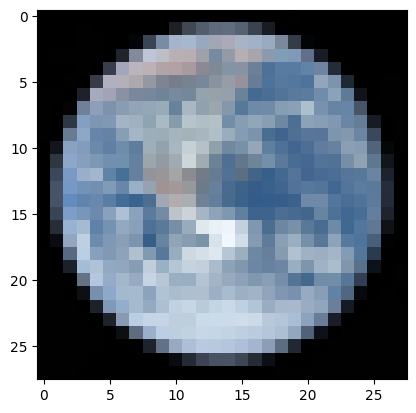

In [82]:
from PIL import ImageOps

border = (58, 2, 58, 2) # left, top, right, bottom
imgprocessed = ImageOps.crop(img, border)
imgprocessed = img.resize((28, 28))

plt.imshow(imgprocessed)

OK, the image has the format we wanted, but it is not still the NumPy array that out model expects. Let's do it.

In [83]:
imgdata = np.asarray(imgprocessed, dtype="uint8")
print(imgdata.shape)
imgdata = imgdata.reshape(1, -1)
print(imgdata.shape)

row = pd.DataFrame(imgdata, columns=['pixel'+str(i) for i in range(size)])
row_scaled = scaler.transform(row) # remember that we trained our models with standarized data

(28, 28, 3)
(1, 2352)


In [84]:
model.predict(row.values)

array(['Saturn'], dtype=object)

1. Observe that despite having a classifier with 99% accuracy, it classifies 'Earth' as 'Saturn'. So bad!. How do you explain this bad behaviour?

El modelo solo generaliza bien dentro de la distribución de datos con la que lo hemos entrenado.

El dataset de entrenamiento tiene características muy particulares:
- Fondo negro uniforme
- Planeta centrado en la imagen
- Tamaño y resolución normalizados (28×28 px)

La imagen descargada de Earth desde GitHub es una fotografía real con:
- Colores y contraste distintos a las imágenes de entrenamiento
- Diferencia en el recorte o el centrado del planeta

El KNN con K=1 clasifica basándose en distancia euclidiana píxel a píxel. Si la imagen real de La Tierra se parece más (en el espacio de píxeles) a las imágenes de Saturno del training set que a las de La Tierra, la predicción será Saturno — aunque para un humano sea obviamente la Tierra.

**Conclusión**: un modelo con alta accuracy en test no garantiza buen rendimiento en producción si los datos nuevos tienen una distribución diferente a los datos de entrenamiento. 